In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import json
from tensorflow.keras.preprocessing import image

In [5]:
# Load class names
with open('class_names.json', 'r') as f:
    class_names = json.load(f)

# Load the multi-output model
model = tf.keras.models.load_model('acne_model.keras')
print("Model loaded successfully!")

Model loaded successfully!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
============== Hasil Prediksi ==============
Barier: 0.17%
Berminyak: 0.81%
Blackheads: 26.18%
Bopeng: 1.30%
Cyst: 25.20%
Papules: 26.31%
Pustules: 26.01%
Whiteheads: 10.57%


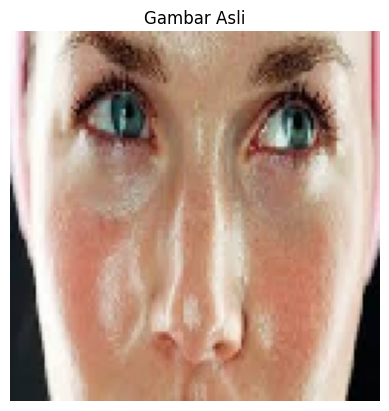

In [6]:
# Path to the image (images.jpeg yang ada di root directory)
img_path = '../images.jpeg'

# Ukuran gambar yang digunakan saat training
IMAGE_SIZE = 128

# Load dan preprocessing gambar
img = image.load_img(img_path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) # Tambahkan dimensi batch
img_array = img_array / 255.0 # Normalisasi gambar (sesuai tahap training)

# Lakukan prediksi
predictions = model.predict(img_array)

# Tampilkan hasil prediksi dari multiple output
print('============== Hasil Prediksi ==============')
for i, class_name in enumerate(class_names):
    # Multi-label probability: kalikan dengan 100 untuk persentase
    persentase = predictions[0][i] * 100
    print(f'{class_name}: {persentase:.2f}%')
print('============================================')

# Tampilkan gambar
plt.imshow(img)
plt.title('Gambar Asli')
plt.axis('off')
plt.show()